In [1]:
import importlib
import os
import numpy as np
import pandas as pd

try:
    from pandas_market_calendars import get_calendar
    HAS_MARKET_CAL = True
except ImportError:
    HAS_MARKET_CAL = False
    print("Warning: pandas_market_calendars not installed. Using weekday count instead.")
    print("Install with: pip install pandas_market_calendars")

from upgraded_utilities import save_models_data, plot_candlestick_graphs, plot_mp_graphs

from backtest import main as bt

from model_evaluator import main as me

In [28]:
# Hyperparemeter Tuning toggle
RUN_TUNING = False

# Which tuning method(s) to run - Can be any subset of: "grid", "random", "bayesian"
TUNING_METHOD = "random"

# Which models to tune — None tunes all models in TUNABLE_MODELS.
# If only some need tuning, provide a list such as ["Modularised_ANN", "Modularised_DTR"]
TUNING_MODELS = None

# Shared tuning parameters — used by all three tuning methods
TUNING_KWARGS = dict(
    start_date = "2010-01-01",
    end_date = "2025-12-31",
    data_split_ratios = (0.8, 0.1, 0.1),
    n_steps = 5,
    rmse_mode = "price",
)

# Method-specific overrides (merged with TUNING_KWARGS when tuning is turned on).

# No additional kwargs needed
GRID_KWARGS    = {}
# Keep a fixed seed for consistency and determinism
RANDOM_KWARGS  = dict(n_trials=20, seed=42)
BAYESIAN_KWARGS = dict(n_trials=25, n_initial=5)


# --- Configure prediction horizon ---
# Set your target end date for predictions
END_DATE = "2027-04-18"

# Load just the data dates to find the last one
df_dates = pd.read_csv("Data/S&P 500 Composite.csv", usecols=["YYYYMMDD"])
df_dates["Date"] = pd.to_datetime(df_dates["YYYYMMDD"], format="%Y%m%d")
last_data_date = df_dates["Date"].max()
last_data_date_str = last_data_date.strftime("%Y-%m-%d")

In [29]:
# Calculate N_STEPS using actual NYSE trading calendar
if HAS_MARKET_CAL:
    try:
        nyse = get_calendar('NYSE')
        # Get all trading days between last data date and END_DATE
        trading_days = nyse.sessions_window(last_data_date, END_DATE)
        # N_STEPS is the count of trading days (excluding the start date)
        N_STEPS = max(1, len(trading_days) - 1)
        print(f"Using NYSE calendar: {N_STEPS} trading days from {last_data_date_str} to {END_DATE}")
    except Exception as e:
        print(f"Error using NYSE calendar: {e}")
        print("Falling back to weekday count...")
        start = np.datetime64(last_data_date_str, 'D')
        end = np.datetime64(END_DATE, 'D')
        N_STEPS = max(1, int(np.busday_count(start, end)))
        print(f"Predicting {N_STEPS} trading days (weekday estimate) to {END_DATE}")
else:
    # Fallback to weekday count if market calendars not available
    start = np.datetime64(last_data_date_str, 'D')
    end = np.datetime64(END_DATE, 'D')
    N_STEPS = max(1, int(np.busday_count(start, end)))
    print(f"Predicting {N_STEPS} trading days (weekday estimate) to {END_DATE}")

print(f"Last data date: {last_data_date_str}")
# --- End configuration ---

Error using NYSE calendar: 'NYSEExchangeCalendar' object has no attribute 'sessions_window'
Falling back to weekday count...
Predicting 338 trading days (weekday estimate) to 2027-04-18
Last data date: 2025-12-31


In [30]:
if RUN_TUNING:
    if TUNING_METHOD == "grid":
        from Tuning.run_grid_search import run_all as _tune
        _tune(models=TUNING_MODELS, **TUNING_KWARGS, **GRID_KWARGS)

    elif TUNING_METHOD == "random":
        from Tuning.run_random_search import run_all as _tune
        _tune(models=TUNING_MODELS, **TUNING_KWARGS, **RANDOM_KWARGS)

    elif TUNING_METHOD == "bayesian":
        from Tuning.run_bayesian_opt import run_all as _tune
        _tune(models=TUNING_MODELS, **TUNING_KWARGS, **BAYESIAN_KWARGS)

    else:
        raise ValueError(f"Unknown TUNING_METHOD={TUNING_METHOD!r}. Please choose from 'grid', 'random', or 'bayesian'.")

In [31]:
# Now evaluate the models

# All the model files are in a subdirectory called Models, all end in .py and any files to not be tested should start with _
files = [f[:-3] for f in os.listdir("./Models") if f.endswith(".py") and not f.startswith("_")]

# Stores the main function for each model as the value, with the key being the name of the file
models = {}
# Stores a pandas dataframe outputted by the main function from each model as the value, with the key being the name of the model's file
model_results = {}

# Try each model, if it has a 'main' function, execute it and record the results
for name in files:
    module = importlib.import_module(f"Models.{name}")
    if hasattr(module, "main"):
        models[name] = module.main
    else:
        print(f"{name} has no main() — skipping")
"""
# Iterates through every model, retrieving the name and main function
for name, main_function in models.items():
    try:
        # Each model returns a DataFrame with columns:
        # open_rel, high_rel, low_rel, close_rel, open, high, low, close
        # And the daisy chained versions for each, where the relatives (returns) should be identical to before,
        # but are displayed as a sanity check - if unequal there's an error
        model_results[name] = main_function(END_DATE=END_DATE, N_STEPS=N_STEPS)
    except Exception as e:
        print(f"{name} failed: {e}")
"""

'\n# Iterates through every model, retrieving the name and main function\nfor name, main_function in models.items():\n    try:\n        # Each model returns a DataFrame with columns:\n        # open_rel, high_rel, low_rel, close_rel, open, high, low, close\n        # And the daisy chained versions for each, where the relatives (returns) should be identical to before,\n        # but are displayed as a sanity check - if unequal there\'s an error\n        model_results[name] = main_function(END_DATE=END_DATE, N_STEPS=N_STEPS)\n    except Exception as e:\n        print(f"{name} failed: {e}")\n'

In [16]:
# Iterates through every model, retrieving the name and main function
for name, main_function in models.items():
    try:
        # Each model returns a DataFrame with columns:
        # open_rel, high_rel, low_rel, close_rel, open, high, low, close
        # And the daisy chained versions for each, where the relatives (returns) should be identical to before,
        # but are displayed as a sanity check - if unequal there's an error
        model_results[name] = main_function(
            END_DATE=END_DATE,
            # Always 1-step for train/test
            N_STEPS=1,
            # The large computed horizon for future predictions
            FUTURE_STEPS=N_STEPS
        )
    except Exception as e:
        print(f"{name} failed: {e}")

[*********************100%***********************]  1 of 1 completed


ANN (1-step ahead) RMSE [price]: {'open': 54.93259932220602, 'high': 43.02680085227858, 'low': 43.47715682600847, 'close': 27.640083783618675, 'mean': 42.26916019602794}


[*********************100%***********************]  1 of 1 completed


CNN-LSTM (1-step ahead) RMSE [price]: {'open': 55.24477152235905, 'high': 50.678362007438736, 'low': 45.815530630595916, 'close': 31.94676803603133, 'mean': 45.92135804910625}


[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed


Pattern KNN (k=2, 1-step ahead) RMSE [price]: {'open': 54.90634682302122, 'high': 31.751944394646404, 'low': 30.097288465009868, 'close': 44.9808665914558, 'mean': 40.434111568533325}


[*********************100%***********************]  1 of 1 completed


Pattern KNN Prices (k=2, 1-step ahead) RMSE [price]: {'open': 54.90634682302122, 'high': 31.751944394646404, 'low': 30.097288465009868, 'close': 44.9808665914558, 'mean': 40.434111568533325}


[*********************100%***********************]  1 of 1 completed


%matplotlib inline

Newest Results/LSTM.csv
Newest Results/Modularised_ANN.csv
Newest Results/Modularised_CNN-LSTM.csv
Newest Results/Modularised_CNN_LSTM_DETERMINISTIC_VERSION.csv
Newest Results/Modularised_CNN_LSTM_DETERMINISTIC_VERSION_V2.csv
Newest Results/Modularised_DTR.csv
Newest Results/Modularised_GRU.csv
Newest Results/Modularised_GRU_For_All_Value_Predictors.csv
Newest Results/Modularised_KNN.csv
Newest Results/Modularised_KNN_With_Pattern_Matching.csv
Newest Results/Modularised_KNN_With_Pattern_Matching_Predicting_PRICES.csv
Newest Results/random forest.csv
Newest Results/SVR.csv

Strategy                     Return  Final Value
   +79.3%  $ 17,932.11 Buy and Hold             
 +8941.7%  $904,174.85 Best Case Scenario       
   -99.5%  $     48.61 Worst Case Scenario      
   -50.2%  $  4,980.62 Random Choices           
   -48.0%  $  5,201.47 Newest Results/LSTM      
  +118.9%  $ 21,891.71 Newest Results/Modularised_ANN
  +130.8%  $ 23,075.21 Newest Results/Modularised_CNN-LSTM
  +140.6%  $ 

c:\Users\tcamp\Desktop\A - University Work\Year 2\COMP208\Playground\14-04-2026 - Models + Hyper tuning\backtest.py:113: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  predicted_series = pd.Series(predictions, index=pd.to_datetime(prediction_dates))
c:\Users\tcamp\Desktop\A - University Work\Year 2\COMP208\Playground\14-04-2026 - Models + Hyper tuning\backtest.py:113: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  predicted_series = pd.Series(predictions, index=pd.to_datetime(prediction_dates))


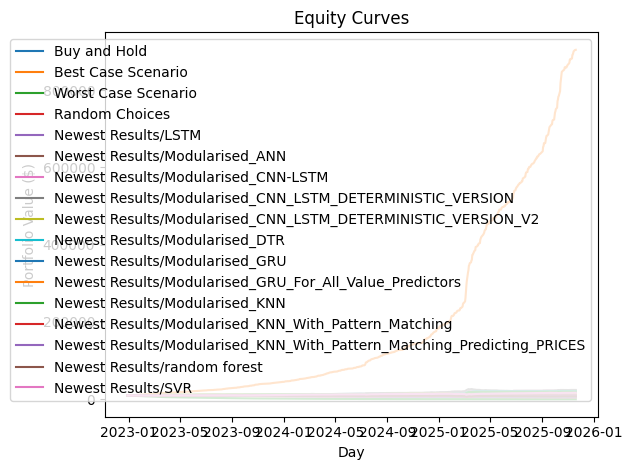

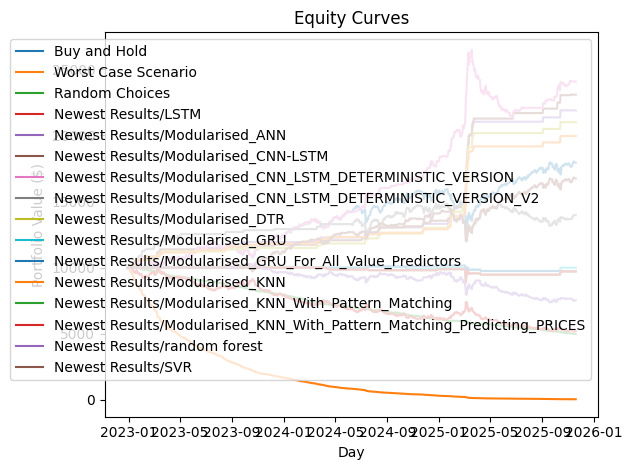

c:\Users\tcamp\Desktop\A - University Work\Year 2\COMP208\Playground\14-04-2026 - Models + Hyper tuning\model_evaluator.py:11: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt_idx = pd.to_datetime(idx, dayfirst=True)
c:\Users\tcamp\Desktop\A - University Work\Year 2\COMP208\Playground\14-04-2026 - Models + Hyper tuning\model_evaluator.py:11: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt_idx = pd.to_datetime(idx, dayfirst=True)
c:\Users\tcamp\Desktop\A - University Work\Year 2\COMP208\Playground\14-04-2026 - Models + Hyper tuning\model_evaluator.py:11: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt_idx = pd.to_datetime(idx, dayfirst=True)
c:\Users\tcamp\Desktop\A - University Wo

Skipping LSTM.csv, missing columns: ['open', 'high', 'low']



Modularised_ANN
{'mae_open': np.float64(20.741649933604208), 'mse_open': np.float64(480.9574216383098), 'rmse_open': np.float64(20.741649933604208), 'r2_open': np.float64(0.9993731329117641), 'dir_acc_open': np.float64(0.9827814569536424), 'mae_high': np.float64(23.936863633125423), 'mse_high': np.float64(1195.240682597679), 'rmse_high': np.float64(23.936863633125423), 'r2_high': np.float64(0.9984507099416042), 'dir_acc_high': np.float64(0.7456953642384105), 'mae_low': np.float64(18.956734840274965), 'mse_low': np.float64(1053.6740169884683), 'rmse_low': np.float64(18.956734840274965), 'r2_low': np.float64(0.9986188284586617), 'dir_acc_low': np.float64(0.7827814569536424), 'mae_close': np.float64(29.47056595745114), 'mse_close': np.float64(1831.751215650823), 'rmse_close': np.float64(29.47056595745114), 'r2_close': np.float64(0.9976188905156539), 'dir_acc_close': np.float64(0.5920529801324503), 'model': 'Modularised_ANN'}



In [7]:
"""# --- Save all the models data into CSV files ---
for name in models.keys():
    try:
        save_models_data(name, model_results[name])
    except Exception as e:
        print(f"Failed saving {name} - with error {e}")


# Display the results in a candlestick plot and save the matplotlib plots
for name, df in model_results.items():
    print(name)
    # Call the plot matplot lib graphs function to render and save those plots
    plot_mp_graphs(df, name, save=True, show=False)
    # And call the pyplot candlesticks function to render, save and display those results
    plot_candlestick_graphs(df, name, save=True, show=False)
"""

# Now run the backtest!
bt(save=True, show=True)

# And get metrics for each file!
me()